# Proyeccion a futuro (10 anios) de la brecha salarial y pobreza en Mexico.

Para realizar la proyeccion de 2025-2034 de la brecha de ingreso y pobreza de hombres y mujeres se utilizara el algoritmo de regresion lineal, el algoritmo de Holt-Winters, el algoritmo SARIMA y el algoritmo Prophet (los ultimos tres especializados en proyecciones a futuro de datos de series de tiempo).

In [25]:
# Bibliotecas usadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings("ignore")


In [26]:
# Leemos los datos (del dataset maestro)
df = pd.read_csv("../data/dataset_final_tablero.csv")

# Mapeo de los "cuartos" de anio
trim_map = {"I": 0.0, "II": 0.25, "III": 0.5, "IV": 0.75}

#Limpieza de datos nulos
df["t"] = df["anio"] + df["trimestre"].map(trim_map)
df = df.dropna().reset_index(drop=True)

In [27]:
N_HIST    = len(df)
N_FUTURE  = 40          # 10 años × 4 trimestres
S         = 4           # estacionalidad trimestral
t_hist    = df["t"].values
t_future  = np.array([t_hist[-1] + 0.25*(i+1) for i in range(N_FUTURE)])
t_all     = np.concatenate([t_hist, t_future])

TARGETS = {
    "pobreza_total":    ("% Pobreza Nacional",    "#E63946"),
    "pobreza_hombres":  ("% Pobreza Hombres",     "#457B9D"),
    "pobreza_mujeres":  ("% Pobreza Mujeres",     "#E76F51"),
    "ingreso_hombres":  ("Ingreso Hombres (MXN)", "#2A9D8F"),
    "ingreso_mujeres":  ("Ingreso Mujeres (MXN)", "#F4A261"),
    "brecha_salarial":  ("Brecha Salarial %",      "#9B2226"),
}


### Implementacion del algoritmo de regresion lineal

In [28]:
# ==== IMPLEMENTACION DE REGRESION POLINOMICA (GRADO 2) ====
def regresion_polinomica_g2(t, y, t_future):
    """
    Ajusta un modelo de regresión polinómica de grado 2.
    Fórmula: y = ax^2 + bx + c
    """
    # 1. Ajuste del modelo polinómico
    coefs = np.polyfit(t, y, deg=2)
    poly_func = np.poly1d(coefs)
    
    # 2. Obtener valores ajustados en histórico y proyectados
    fitted = poly_func(t)
    forecast = poly_func(t_future)
    
    # 3. Calcular el error de los residuales para generar las bandas
    residuals = y - fitted
    std_error = np.std(residuals)
    
    # 4. Aproximación con Z-scores para bandas al 80% (1.28) y 95% (1.96)
    lo80 = forecast - 1.28 * std_error
    hi80 = forecast + 1.28 * std_error
    lo95 = forecast - 1.96 * std_error
    hi95 = forecast + 1.96 * std_error
    
    return fitted, forecast, lo80, hi80, lo95, hi95

### Implementacion del algoritmo de Holt-Winters

In [29]:
# ==== IMPLEMENTACION DEL ALGORITMO DE HOLT-WINTERS ====
# (ETS Triple — Error Aditivo, Tendencia, Estacional)
def holt_winters(y, n_future, s=4):
    """
    Suavizado exponencial triple (Holt-Winters aditivo).
    Optimiza α, β, γ minimizando MSE en muestra.
    Retorna: (fitted, forecast, lower_80, upper_80, lower_95, upper_95)
    """
    n = len(y)

    def hw_fit(params):
        alpha, beta, gamma = params
        if not (0 < alpha < 1 and 0 < beta < 0.3 and 0 < gamma < 1):
            return 1e10
        # Inicialización
        L = np.mean(y[:s])
        T = (np.mean(y[s:2*s]) - np.mean(y[:s])) / s
        I = y[:s] - L
        errors = []
        Ls, Ts, Is = [L], [T], list(I)
        for t in range(n):
            if t < s:
                yhat = L + T + I[t % s]
            else:
                yhat = Ls[-1] + Ts[-1] + Is[-s]
            e = y[t] - yhat
            errors.append(e)
            L_new = alpha * (y[t] - Is[-s if t >= s else t % s]) + (1 - alpha) * (Ls[-1] + Ts[-1])
            T_new = beta  * (L_new - Ls[-1]) + (1 - beta) * Ts[-1]
            I_new = gamma * (y[t] - L_new)   + (1 - gamma) * Is[-s if t >= s else t % s]
            Ls.append(L_new); Ts.append(T_new); Is.append(I_new)
        return np.mean(np.array(errors)**2)

    res = minimize(hw_fit, x0=[0.3, 0.05, 0.3],
                   bounds=[(0.01,0.99),(0.001,0.29),(0.01,0.99)],
                   method="L-BFGS-B")
    alpha, beta, gamma = res.x

    # Re-ajuste completo para obtener valores
    L = np.mean(y[:s])
    T = (np.mean(y[s:2*s]) - np.mean(y[:s])) / s
    I = list(y[:s] - L)
    fitted, Ls, Ts = [], [L], [T]
    for t in range(n):
        yhat = Ls[-1] + Ts[-1] + I[-s if t >= s else t % s]
        fitted.append(yhat)
        L_new = alpha * (y[t] - I[-s if t >= s else t % s]) + (1 - alpha) * (Ls[-1] + Ts[-1])
        T_new = beta  * (L_new - Ls[-1]) + (1 - beta) * Ts[-1]
        I_new = gamma * (y[t] - L_new)   + (1 - gamma) * I[-s if t >= s else t % s]
        Ls.append(L_new); Ts.append(T_new); I.append(I_new)

    # Proyección
    forecast = []
    for h in range(1, n_future + 1):
        f = Ls[-1] + h * Ts[-1] + I[-s + ((h - 1) % s)]
        forecast.append(f)

    # Intervalos de confianza basados en residuos
    residuals = np.array(y) - np.array(fitted)
    sigma = np.std(residuals)
    h_arr = np.arange(1, n_future + 1)
    se = sigma * np.sqrt(h_arr)          # crece con el horizonte
    forecast = np.array(forecast)
    return (np.array(fitted), forecast,
            forecast - 1.28*se, forecast + 1.28*se,   # 80%
            forecast - 1.96*se, forecast + 1.96*se)   # 95%

### Implementacion manual del algoritmo de SARIMA simplificado

In [30]:
# ==== IMPLEMENTACION DE SARIMA SIMPLIFICADO ===
# (AR(2) + componente estacional AR(1))

def sarima(y, n_future, p=2, d=1, s=4, P=1):
    """
    SARIMA(p,d,0)(P,1,0)[s] simplificado.
    - Diferencia una vez (d=1) + diferencia estacional (D=1)
    - Ajusta AR(p) + SAR(P) sobre la serie diferenciada
    - Proyecta iterativamente
    """
    n = len(y)

    # Diferenciación
    dy  = np.diff(y, n=d)                          # diferencia regular
    dsy = dy[s:] - dy[:-s]                          # diferencia estacional

    # Features: lags AR(p) + lag estacional SAR(P)
    max_lag = max(p, s * P)
    X, yy = [], []
    for i in range(max_lag, len(dsy)):
        row = [dsy[i - k] for k in range(1, p + 1)]
        row += [dsy[i - s * k] for k in range(1, P + 1)]
        X.append(row); yy.append(dsy[i])

    X  = np.array(X); yy = np.array(yy)
    # OLS
    coef, *_ = np.linalg.lstsq(
        np.column_stack([np.ones(len(X)), X]), yy, rcond=None)
    intercept = coef[0]; phi = coef[1:]

    # Reconstruir la serie diferenciada con ajuste
    dsy_full  = list(dsy)
    resid_fit = []
    for i in range(max_lag, len(dsy)):
        row = [dsy_full[i - k] for k in range(1, p + 1)]
        row += [dsy_full[i - s * k] for k in range(1, P + 1)]
        yhat = intercept + np.dot(phi, row)
        resid_fit.append(dsy_full[i] - yhat)

    sigma = np.std(resid_fit)

    # Proyección iterativa
    dsy_ext = list(dsy)
    for _ in range(n_future):
        row = [dsy_ext[-k] for k in range(1, p + 1)]
        row += [dsy_ext[-s * k] for k in range(1, P + 1)]
        next_val = intercept + np.dot(phi, row)
        dsy_ext.append(next_val)

    dsy_forecast = np.array(dsy_ext[-n_future:])

    # Revertir diferencia estacional → dy
    dy_ext = list(dy)
    for val in dsy_forecast:
        dy_ext.append(val + dy_ext[-s])

    dy_forecast = np.array(dy_ext[-n_future:])

    # Revertir diferencia regular → y
    y_ext = list(y)
    for val in dy_forecast:
        y_ext.append(val + y_ext[-1])

    forecast   = np.array(y_ext[-n_future:])
    fitted_raw = np.array(y_ext[d + s: d + s + n - d - s])
    # Fitted para toda la serie (extendido con los primeros valores reales)
    pad    = n - len(fitted_raw)
    fitted = np.concatenate([y[:pad], fitted_raw])

    # Intervalos (varianza crece con h^0.5)
    h_arr = np.arange(1, n_future + 1)
    se    = sigma * np.sqrt(h_arr)
    return (fitted, forecast,
            forecast - 1.28*se, forecast + 1.28*se,
            forecast - 1.96*se, forecast + 1.96*se)


### Implementacion de Pophet

In [31]:
# PROPHET-STYLE (Tendencia lineal por tramos + Fourier estacional)
def prophet_style(t, y, t_future):
    """
    Modelo descomponible:
      y(t) = tendencia(t) + estacionalidad_fourier(t) + ruido
    Tendencia: regresión lineal con posibles changepoints
    Estacionalidad: series de Fourier (K=3 armónicos, periodo=1 año)
    """
    n = len(t)
    K = 3           # armónicos de Fourier
    period = 1.0    # 1 año (nuestro t está en unidades de año)

    def fourier_features(tt, K=K, period=period):
        feats = []
        for k in range(1, K + 1):
            feats.append(np.sin(2 * np.pi * k * tt / period))
            feats.append(np.cos(2 * np.pi * k * tt / period))
        return np.column_stack(feats)

    # Changepoints automáticos (cada ~2 años)
    n_cp   = 8
    cp_idx = np.linspace(int(n * 0.1), int(n * 0.9), n_cp, dtype=int)
    cps    = t[cp_idx]

    def trend_features(tt, cps=cps):
        base = np.column_stack([np.ones(len(tt)), tt])
        for cp in cps:
            base = np.column_stack([base, np.maximum(0, tt - cp)])
        return base

    # Matriz de diseño
    def design(tt):
        return np.column_stack([trend_features(tt), fourier_features(tt)])

    X_train = design(t)
    # Ridge regression (λ = 0.01) para estabilidad
    lam = 0.01
    A   = X_train.T @ X_train + lam * np.eye(X_train.shape[1])
    b   = X_train.T @ y
    coef = np.linalg.solve(A, b)

    fitted   = design(t)        @ coef
    forecast = design(t_future) @ coef

    residuals = y - fitted
    sigma     = np.std(residuals)
    h_arr     = np.arange(1, len(t_future) + 1)
    se        = sigma * (1 + 0.02 * np.sqrt(h_arr))  # incertidumbre moderada

    return (fitted, forecast,
            forecast - 1.28*se, forecast + 1.28*se,
            forecast - 1.96*se, forecast + 1.96*se)


#### AJUSTE DE LOS MODELOS

In [32]:
print("Ajustando modelos… esto puede tardar ~30 segundos")
results = {}

for col, (label, color) in TARGETS.items():
    y = df[col].values
    print(f"  • {label}")

    # Ejecucion de algoritmos
    poly = regresion_polinomica_g2(t_hist, y, t_future)  # <-- NUEVA LÍNEA
    hw  = holt_winters(y, N_FUTURE, s=S)
    sar = sarima(y, N_FUTURE, p=2, d=1, s=S, P=1)
    pro = prophet_style(t_hist, y, t_future)

    results[col] = {
        "y":     y,
        "color": color,
        "label": label,
        "hw":    hw,    # (fitted, forecast, lo80, hi80, lo95, hi95)
        "sar":   sar,
        "pro":   pro,
        "poly":  poly
    }

print("Modelos ajustados\n")

Ajustando modelos… esto puede tardar ~30 segundos
  • % Pobreza Nacional
  • % Pobreza Hombres
  • % Pobreza Mujeres
  • Ingreso Hombres (MXN)
  • Ingreso Mujeres (MXN)
  • Brecha Salarial %
Modelos ajustados



In [33]:
# ==== GUARDAR PREDICCIONES EN CSV  ====

csv_data = []

# Mapeo de llaves y nombres amigables de modelos
modelos = {
    "hw": "Holt-Winters",
    "sar": "SARIMA",
    "pro": "Prophet",
    "poly": "Regresion Polinomica (G2)"
}

# Mapeo inverso para reconstruir la columna trimestre
trimestre_map = {0.0: "I", 0.25: "II", 0.5: "III", 0.75: "IV"}

# Extraemos las proyecciones (t_future)
for col, data in results.items():
    for mk, mname in modelos.items():
        # Desempaquetamos la tupla del modelo
        fitted, forecast, lo80, hi80, lo95, hi95 = data[mk]
        
        for i, t_val in enumerate(t_future):
            # Reconstrucción de fecha
            anio = int(t_val)
            frac = round(t_val - anio, 2)
            trimestre_str = trimestre_map.get(frac, "I")
            
            # Guardado en formato Tidy
            csv_data.append({
                "tiempo_t": t_val,
                "anio": anio,
                "trimestre": trimestre_str,
                "variable": col,
                "modelo": mname,
                "prediccion": forecast[i],
                "lim_inf_80": lo80[i],
                "lim_sup_80": hi80[i],
                "lim_inf_95": lo95[i],
                "lim_sup_95": hi95[i]
            })

df_predicciones = pd.DataFrame(csv_data)
df_predicciones.to_csv("../data/clean_data/proyecciones.csv", index=False)

print("Archivo generado exitosamente")
display(df_predicciones.head())

Archivo generado exitosamente


,tiempo_t,anio,trimestre,variable,modelo,prediccion,lim_inf_80,lim_sup_80,lim_inf_95,lim_sup_95
0,2025.00,2025,I,pobreza_total,Holt-Winters,11.594245,10.789084,12.399405,10.361343,12.827147
1,2025.25,2025,II,pobreza_total,Holt-Winters,11.646896,10.508227,12.785564,9.903309,13.390482
2,2025.50,2025,III,pobreza_total,Holt-Winters,12.032919,10.638340,13.427498,9.897470,14.168368
3,2025.75,2025,IV,pobreza_total,Holt-Winters,11.513170,9.902849,13.123491,9.047366,13.978973
4,2026.00,2026,I,pobreza_total,Holt-Winters,11.198965,9.398571,12.999358,8.442112,13.955817


#### Graficacion

In [34]:
plt.style.use("seaborn-v0_8-whitegrid")

C = {
    "hw":   "#3A86FF",   # azul  — Holt-Winters
    "sar":  "#FF006E",   # rosa  — SARIMA
    "pro":  "#FB5607",   # naranja — Prophet-style
    "poly": "#8338EC",
    "fondo":"#F8F9FA",
    "titulo":"#1A1A2E",
}

In [35]:
def plot_series(ax, t_hist, t_future, r_model, key, color_key, label_str):
    """Dibuja datos reales + fitted + forecast + banda 80% + 95%."""
    fitted, forecast, lo80, hi80, lo95, hi95 = r_model[key]
    c = C[color_key]
    # Banda 95%
    ax.fill_between(t_future, lo95, hi95, color=c, alpha=0.10)
    # Banda 80%
    ax.fill_between(t_future, lo80, hi80, color=c, alpha=0.20)
    # Ajuste histórico
    ax.plot(t_hist, fitted, color=c, lw=1.5, ls="--", alpha=0.6)
    # Proyección
    ax.plot(t_future, forecast, color=c, lw=2.4, label=label_str)
    # Valor final
    ax.annotate(f"{forecast[-1]:.1f}",
                xy=(t_future[-1], forecast[-1]),
                fontsize=8.5, color=c, fontweight="bold",
                xytext=(-38, 5), textcoords="offset points")

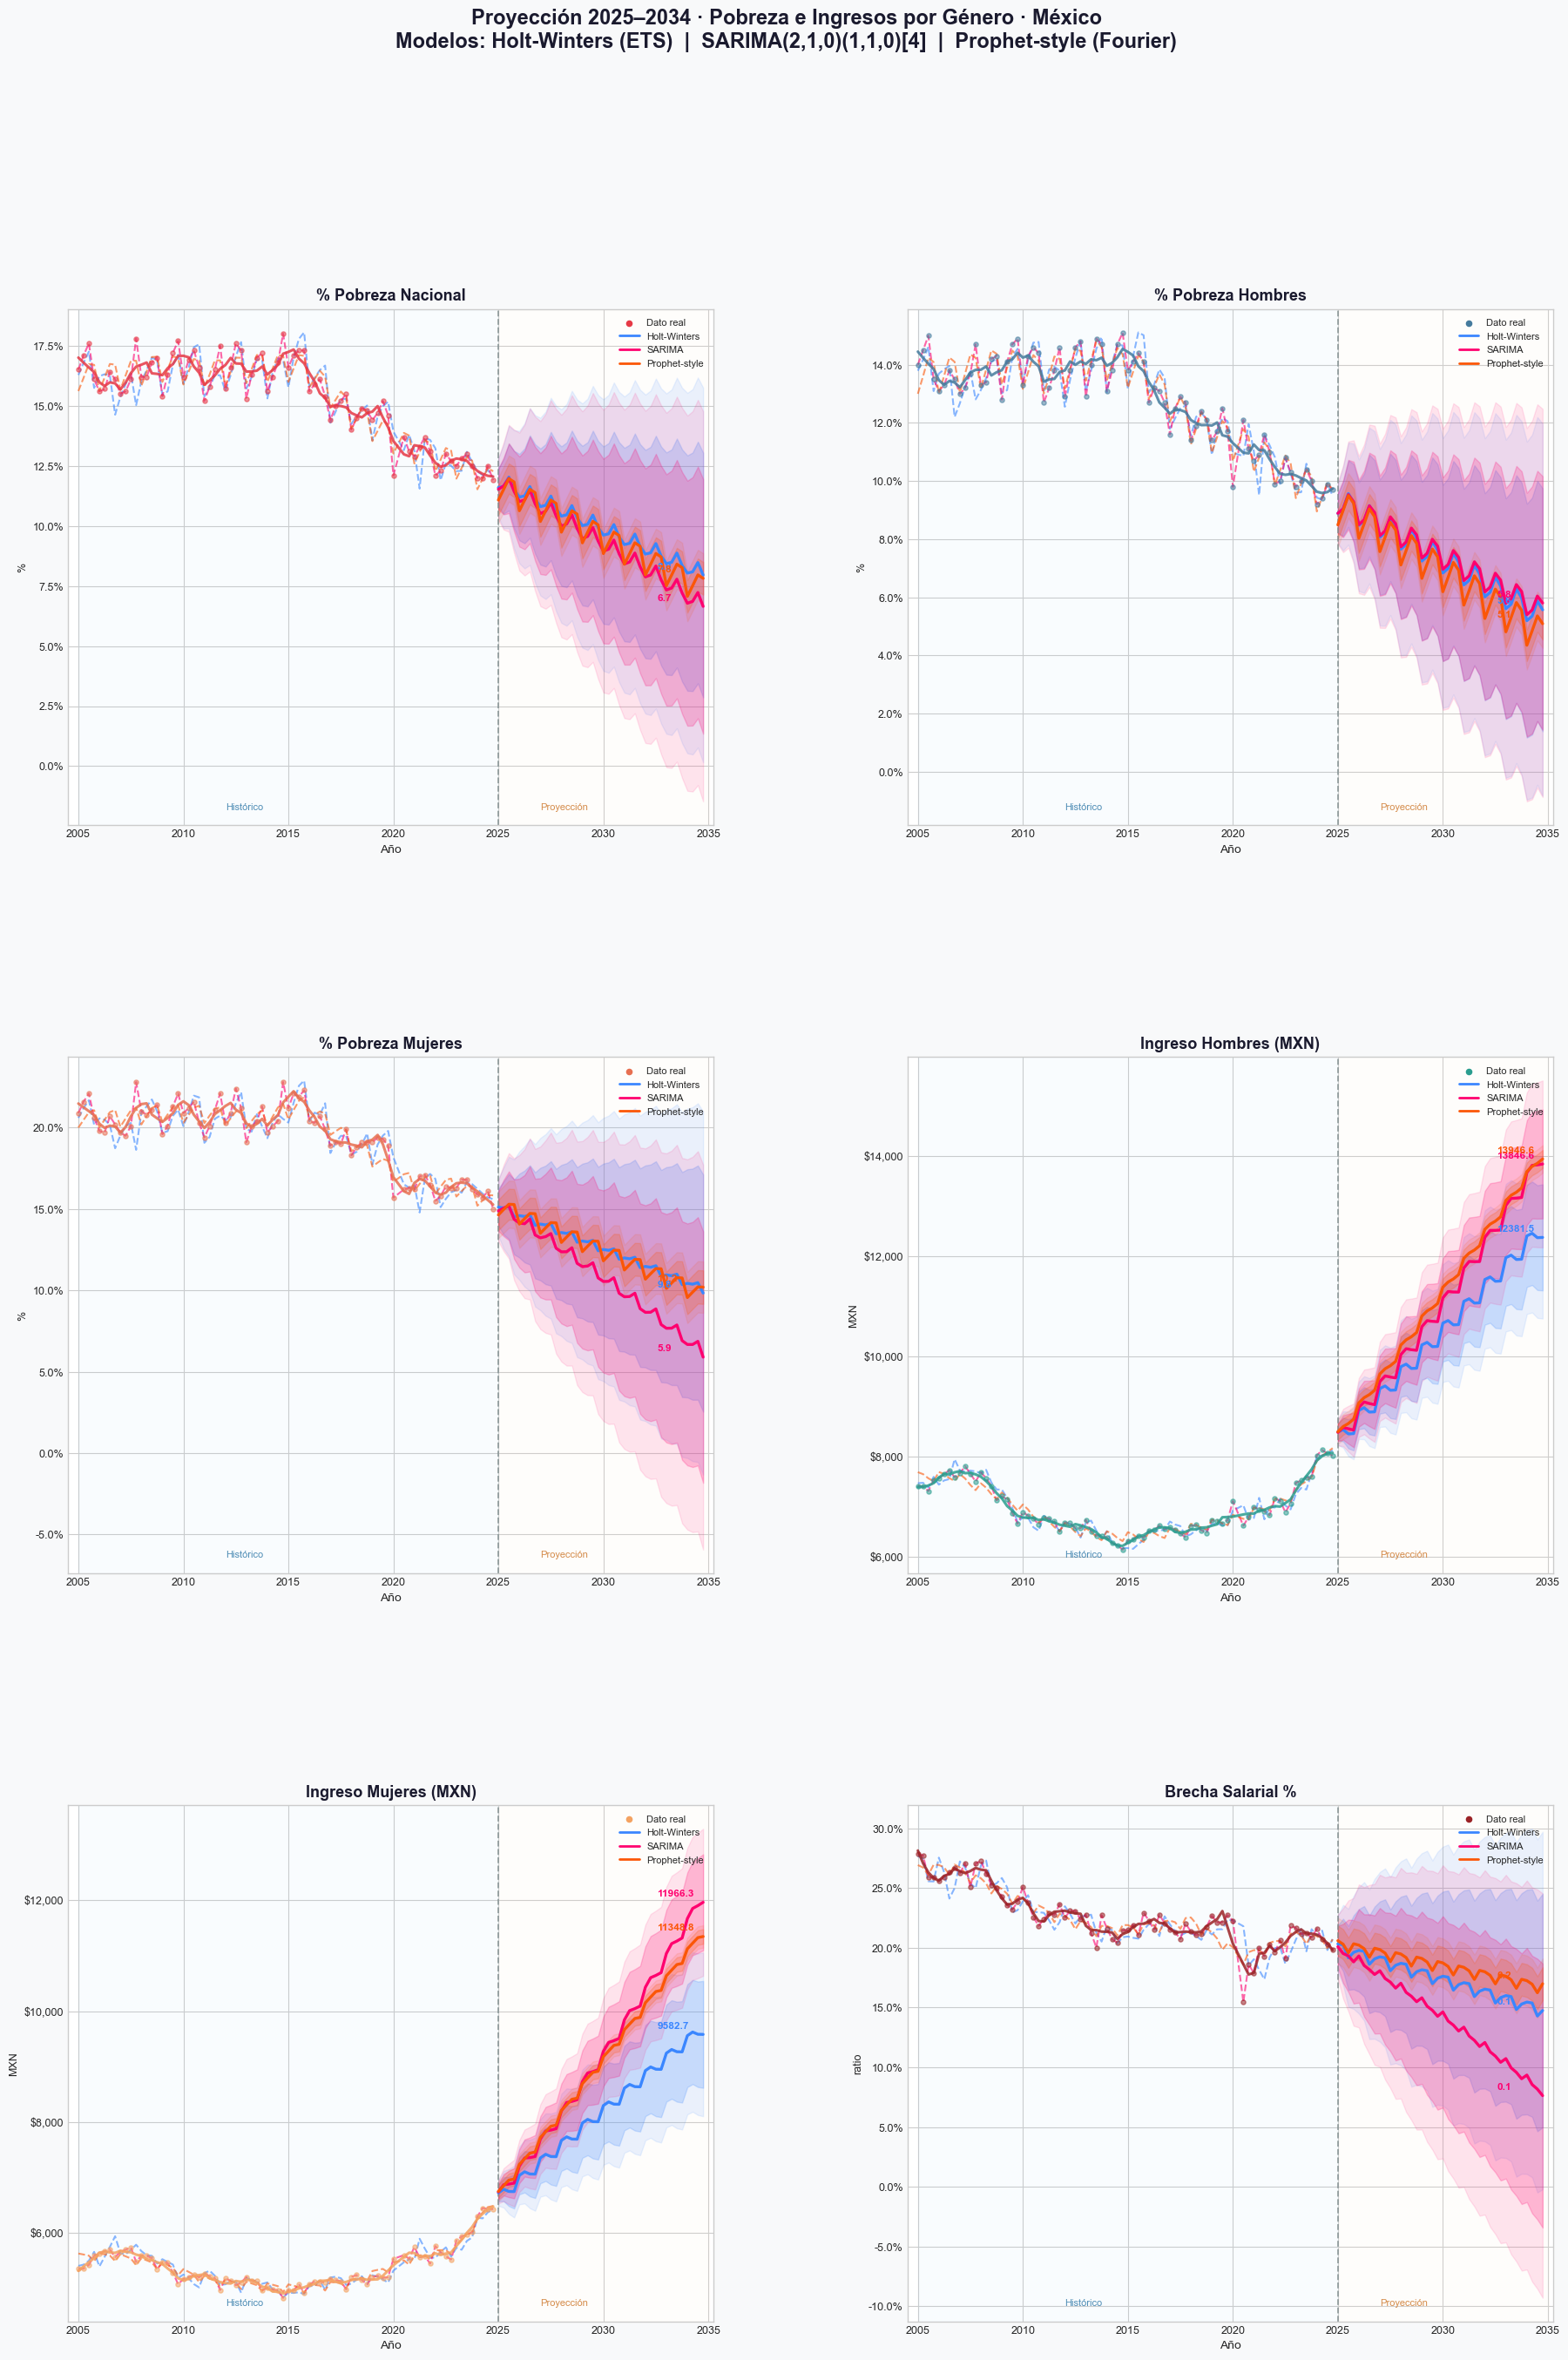

In [36]:
fig = plt.figure(figsize=(22, 30), facecolor=C["fondo"])
fig.suptitle(
    "Proyección 2025–2034 · Pobreza e Ingresos por Género · México\n"
    "Modelos: Holt-Winters (ETS)  |  SARIMA(2,1,0)(1,1,0)[4]  |  Prophet-style (Fourier)",
    fontsize=17, fontweight="bold", color=C["titulo"], y=0.995,
)

gs = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.30)
pos = [
    ("pobreza_total",   0, 0),
    ("pobreza_hombres", 0, 1),
    ("pobreza_mujeres", 1, 0),
    ("ingreso_hombres", 1, 1),
    ("ingreso_mujeres", 2, 0),
    ("brecha_salarial", 2, 1),
]

for col, row, col_idx in pos:
    ax = fig.add_subplot(gs[row, col_idx])
    r  = results[col]

    # Fondo por zona
    ax.axvspan(t_hist.min(), 2025, alpha=0.07, color="#AED6F1")
    ax.axvspan(2025, t_future[-1]+0.3, alpha=0.07, color="#FDEBD0")
    ax.axvline(2025, color="#7F8C8D", lw=1.3, ls="--", alpha=0.8)

    # Datos reales
    ax.scatter(t_hist, r["y"], color=r["color"], s=14, alpha=0.55,
               zorder=5, label="Dato real")

    # Curva suavizada histórica
    smooth = savgol_filter(r["y"], window_length=7, polyorder=2)
    ax.plot(t_hist, smooth, color=r["color"], lw=2.2, alpha=0.85,
            zorder=4, label="_smooth")

    # Modelos
    plot_series(ax, t_hist, t_future, r, "hw",  "hw",  "Holt-Winters")
    plot_series(ax, t_hist, t_future, r, "sar", "sar", "SARIMA")
    plot_series(ax, t_hist, t_future, r, "pro", "pro", "Prophet-style")

    # Etiquetas
    ax.set_title(r["label"], fontsize=13, fontweight="bold",
                 color=C["titulo"], pad=7)
    ax.set_xlabel("Año", fontsize=10)
    is_income = "ingreso" in col
    ax.set_ylabel("MXN" if is_income else ("ratio" if "brecha" in col else "%"),
                  fontsize=9)
    ax.set_xlim(2004.5, t_future[-1] + 0.5)
    ax.tick_params(labelsize=9)

    if is_income:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    elif "brecha" in col:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
    else:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

    # Anotaciones zona
    ylo, yhi = ax.get_ylim()
    yr = yhi - ylo
    ax.text(2012, ylo + 0.03*yr, "Histórico",
            fontsize=8, color="#2471A3", alpha=0.8)
    ax.text(2027, ylo + 0.03*yr, "Proyección",
            fontsize=8, color="#CA6F1E", alpha=0.8)

    # Leyenda
    handles = [
        plt.scatter([], [], color=r["color"], s=20, label="Dato real"),
        plt.Line2D([0],[0], color=C["hw"],  lw=2, label="Holt-Winters"),
        plt.Line2D([0],[0], color=C["sar"], lw=2, label="SARIMA"),
        plt.Line2D([0],[0], color=C["pro"], lw=2, label="Prophet-style"),
    ]
    ax.legend(handles=handles, fontsize=8, loc="best",
              framealpha=0.88, borderpad=0.5)



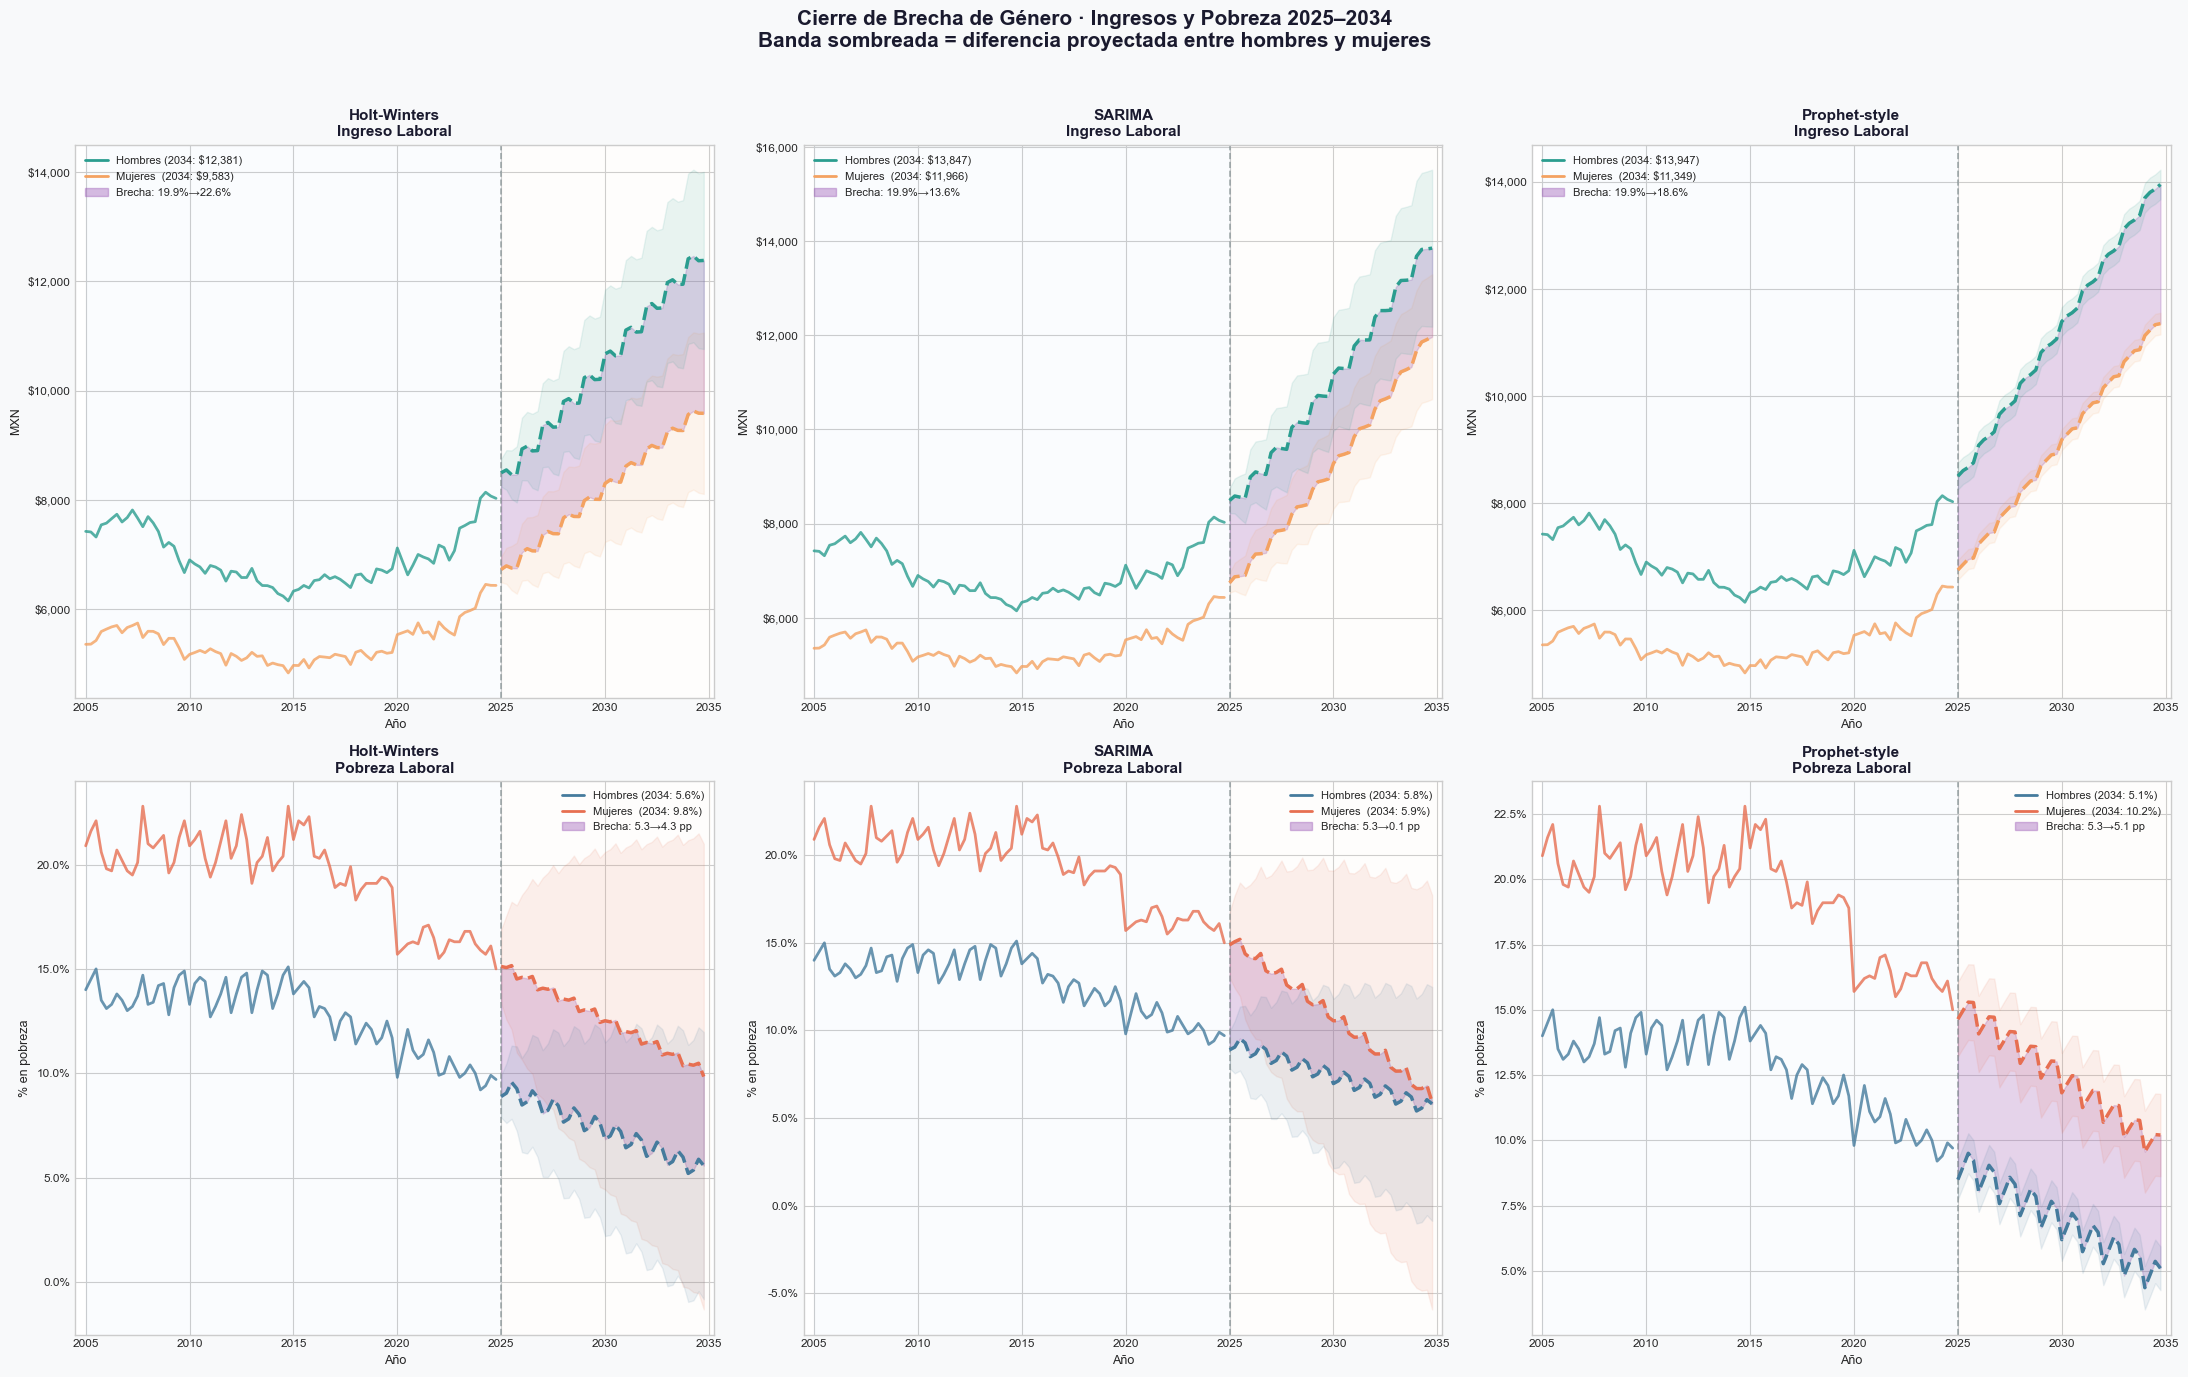

In [37]:
# Figura de brecha
fig2, axes2 = plt.subplots(2, 3, figsize=(22, 14),
                            facecolor=C["fondo"])
fig2.suptitle(
    "Cierre de Brecha de Género · Ingresos y Pobreza 2025–2034\n"
    "Banda sombreada = diferencia proyectada entre hombres y mujeres",
    fontsize=15, fontweight="bold", color=C["titulo"],
)

model_keys  = ["hw",  "sar", "pro", "poly"]
model_names = ["Holt-Winters", "SARIMA", "Prophet-style"]
model_cols  = [C["hw"], C["sar"], C["pro"]]

for j, (mk, mname, mc) in enumerate(zip(model_keys, model_names, model_cols)):

    # ── Ingresos ──
    ax = axes2[0, j]
    rh = results["ingreso_hombres"]
    rm = results["ingreso_mujeres"]

    ax.axvspan(t_hist.min(), 2025, alpha=0.06, color="#AED6F1")
    ax.axvspan(2025, t_future[-1]+0.3, alpha=0.06, color="#FDEBD0")
    ax.axvline(2025, color="#7F8C8D", lw=1.2, ls="--", alpha=0.7)

    # Histórico
    ax.plot(t_hist, rh["y"], color="#2A9D8F", lw=2, alpha=0.8)
    ax.plot(t_hist, rm["y"], color="#F4A261", lw=2, alpha=0.8)

    # Proyección
    fh = rh[mk][1]; fm = rm[mk][1]
    ax.plot(t_future, fh, color="#2A9D8F", lw=2.5, ls="--")
    ax.plot(t_future, fm, color="#F4A261", lw=2.5, ls="--")
    ax.fill_between(t_future, fm, fh, alpha=0.25, color="#9B59B6",
                    label="Brecha proyectada")

    # Banda incertidumbre ingreso mujeres
    ax.fill_between(t_future, rm[mk][4], rm[mk][5],
                    color="#F4A261", alpha=0.10)
    ax.fill_between(t_future, rh[mk][4], rh[mk][5],
                    color="#2A9D8F", alpha=0.10)

    # Brecha % al final
    gap_inicio = (rh["y"][0]  - rm["y"][0])  / rh["y"][0]  * 100
    gap_real   = (rh["y"][-1] - rm["y"][-1]) / rh["y"][-1] * 100
    gap_fin    = (fh[-1] - fm[-1]) / fh[-1] * 100
    ax.set_title(f"{mname}\nIngreso Laboral",
                 fontsize=11, fontweight="bold", color=C["titulo"])
    ax.set_xlabel("Año", fontsize=9)
    ax.set_ylabel("MXN", fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.tick_params(labelsize=8.5)
    ax.set_xlim(2004.5, t_future[-1] + 0.5)

    handles = [
        plt.Line2D([0],[0], color="#2A9D8F", lw=2, label=f"Hombres (2034: ${fh[-1]:,.0f})"),
        plt.Line2D([0],[0], color="#F4A261", lw=2, label=f"Mujeres  (2034: ${fm[-1]:,.0f})"),
        mpatches.Patch(color="#9B59B6", alpha=0.4,
                       label=f"Brecha: {gap_real:.1f}%→{gap_fin:.1f}%"),
    ]
    ax.legend(handles=handles, fontsize=8, loc="upper left", framealpha=0.85)

    # ── Pobreza ──
    ax2 = axes2[1, j]
    rph = results["pobreza_hombres"]
    rpm = results["pobreza_mujeres"]

    ax2.axvspan(t_hist.min(), 2025, alpha=0.06, color="#AED6F1")
    ax2.axvspan(2025, t_future[-1]+0.3, alpha=0.06, color="#FDEBD0")
    ax2.axvline(2025, color="#7F8C8D", lw=1.2, ls="--", alpha=0.7)

    ax2.plot(t_hist, rph["y"], color="#457B9D", lw=2, alpha=0.8)
    ax2.plot(t_hist, rpm["y"], color="#E76F51", lw=2, alpha=0.8)

    fph = rph[mk][1]; fpm = rpm[mk][1]
    ax2.plot(t_future, fph, color="#457B9D", lw=2.5, ls="--")
    ax2.plot(t_future, fpm, color="#E76F51", lw=2.5, ls="--")
    ax2.fill_between(t_future, fph, fpm, alpha=0.25, color="#9B59B6",
                     label="Brecha proyectada")
    ax2.fill_between(t_future, rpm[mk][4], rpm[mk][5],
                     color="#E76F51", alpha=0.10)
    ax2.fill_between(t_future, rph[mk][4], rph[mk][5],
                     color="#457B9D", alpha=0.10)

    gap_pob_real = rpm["y"][-1] - rph["y"][-1]
    gap_pob_fin  = fpm[-1] - fph[-1]

    ax2.set_title(f"{mname}\nPobreza Laboral",
                  fontsize=11, fontweight="bold", color=C["titulo"])
    ax2.set_xlabel("Año", fontsize=9)
    ax2.set_ylabel("% en pobreza", fontsize=9)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))
    ax2.tick_params(labelsize=8.5)
    ax2.set_xlim(2004.5, t_future[-1] + 0.5)

    handles2 = [
        plt.Line2D([0],[0], color="#457B9D", lw=2, label=f"Hombres (2034: {fph[-1]:.1f}%)"),
        plt.Line2D([0],[0], color="#E76F51", lw=2, label=f"Mujeres  (2034: {fpm[-1]:.1f}%)"),
        mpatches.Patch(color="#9B59B6", alpha=0.4,
                       label=f"Brecha: {gap_pob_real:.1f}→{gap_pob_fin:.1f} pp"),
    ]
    ax2.legend(handles=handles2, fontsize=8, loc="upper right", framealpha=0.85)

plt.tight_layout(rect=[0, 0, 1, 0.96])




In [ ]:
# Tabla de resumen numerico
print("\n" + "═"*92)
print("  VALORES PROYECTADOS AL IV TRIMESTRE 2034  (vs. IV-2024 real)")
print("═"*92)

# Se agrega la columna para la Regresión Polinómica
fmt_head = f"{'Variable':<26} {'Real 2024':>10} {'HW 2034':>10} {'SARIMA 2034':>12} {'Prophet 2034':>13} {'Poly G2 2034':>14}"
print(fmt_head)
print("─"*92)

for col, (label, _) in TARGETS.items():
    # Extraemos el último valor de cada proyección
    y_last = results[col]["y"][-1]
    hw_f   = results[col]["hw"][1][-1]
    sar_f  = results[col]["sar"][1][-1]
    pro_f  = results[col]["pro"][1][-1]
    poly_f = results[col]["poly"][1][-1]  
    
    # Formato dependiendo de si es dinero (ingreso) o porcentajes (brecha/pobreza)
    if "ingreso" in col:
        print(f"{label:<26} ${y_last:>8,.0f}  ${hw_f:>8,.0f}  ${sar_f:>10,.0f}  ${pro_f:>11,.0f}  ${poly_f:>12,.0f}")
    elif "brecha" in col:
        print(f"{label:<26}  {y_last*100:>8.1f}%   {hw_f*100:>7.1f}%   {sar_f*100:>9.1f}%   {pro_f*100:>10.1f}%   {poly_f*100:>11.1f}%")
    else:
        print(f"{label:<26}  {y_last:>8.1f}%   {hw_f:>7.1f}%   {sar_f:>9.1f}%   {pro_f:>10.1f}%   {poly_f:>11.1f}%")


════════════════════════════════════════════════════════════════════════════════════════════
  VALORES PROYECTADOS AL IV TRIMESTRE 2034  (vs. IV-2024 real)
════════════════════════════════════════════════════════════════════════════════════════════
Variable                    Real 2024    HW 2034  SARIMA 2034  Prophet 2034   Poly G2 2034
────────────────────────────────────────────────────────────────────────────────────────────
% Pobreza Nacional              11.9%       8.0%         6.7%          7.8%           1.9%
% Pobreza Hombres                9.7%       5.6%         5.8%          5.1%           0.1%
% Pobreza Mujeres               15.0%       9.8%         5.9%         10.2%           3.4%
Ingreso Hombres (MXN)      $   8,026  $  12,381  $    13,847  $     13,947  $      12,349
Ingreso Mujeres (MXN)      $   6,432  $   9,583  $    11,966  $     11,349  $       9,459
Brecha Salarial %               19.9%      14.8%         7.6%         17.0%          24.3%


# Conclusion:
Los modelos implementados hacen un forecasting a traves de metodos estadisticos. Por un lado, la regresion lineal es especialmente optimista en la reduccion de la pobreza, sin embargo, predice que la brecha salarial por genero no disminuira sino por el contrario, aumentara; esto se debe a que es un modelo lineal simple. Por otro lado, los modelos especializados en forecasting de series temporales coinciden en que la brecha de reduce, pero no desaparece por completo. SArima es el mas optimista, mientras que Holt-Winters y Prophet proyectan una reduccion mas moderada de la brecha. Sistematicamente, la pobreza seguira siendo mayor que la masculina en todos los escenarios. Asi, si intervenciones estructurales, el cierre completo de la brecha tomaria decadas mas alla de 2034.